# Analysis for task 2 

For modeling the signed error on the **Y-axis**, we ran the following models: 

- [Lomax](@sec-y-lomax) --- divergent transtiion 
- [Exponential](@sec-y-exponential) 
- [Weibull](@sec-y-weibull) --> This is the best model, will only fit this one. 
- [Log-Normal](@sec-y-logNormal)
- [Gamma](@sec-y-gamma) --- divergent transition 

For modeling the signed error on the **X-axis**, we ran the following models: 

- [Normal](@sec-x-normal)
- [Laplace](@sec-x-laplace) --> This is the best model 
- [Student-t](@sec-x-studentT) --> does not converge. 

In [2]:
import polars as pl
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

In [3]:
task2_df = pl.read_csv("../data/processed/task2.csv")
task2_df

participantId,task,id,rsp_time,status,data.select.x,data.select.y,pixel.select.x,pixel.select.y,param.mu,param.sigma,param.lambda,param.p,param.q,data.ans.x,data.ans.y,data.left.grad,data.right.grad,pixelToMM,dist_to_screen,phy.select.x,phy.select.y,va.select.x,va.select.y,pixel.ans.x,pixel.ans.y,phy.ans.x,phy.ans.y,va.ans.x,va.ans.y,flat
str,str,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""67f03733938aa3f0d17ce8a8""","""task2""",1,9.929,"""completed""",-0.97,0.411236,265.605,247.561915,-1.05,0.78,0.11,4.13,19.23,-1.05,0.411238,0.505667,-0.276714,4.6,668.258963,46.870652,35.312627,4.016991,3.026961,261.325,247.560951,45.940217,35.312837,3.937313,3.026979,0.39119
"""67f03733938aa3f0d17ce8a8""","""task2""",2,5.912,"""completed""",-0.53,0.625103,289.145,163.084211,-0.5,0.57,0.1,2.77,13.06,-0.5,0.625175,0.488223,-0.612249,4.6,668.258963,51.988043,53.677346,4.455151,4.599764,290.75,163.055886,52.336957,53.683503,4.485021,4.600291,0.550236
"""67f03733938aa3f0d17ce8a8""","""task2""",3,8.642,"""completed""",-0.05,0.26932,314.825,303.61862,-0.15,1.16,0.08,4.88,17.4,-0.15,0.26932,0.062015,-0.029176,4.6,668.258963,57.570652,23.126387,4.932994,1.982633,309.475,303.618588,56.407609,23.126394,4.833457,1.982633,0.045596
"""67f03733938aa3f0d17ce8a8""","""task2""",4,8.547,"""completed""",-0.14,0.297357,310.01,292.543793,-0.36,1.07,-0.7,4.99,11.58,-0.36,0.300822,0.005766,-0.000045,4.6,668.258963,56.523913,25.533958,4.843411,2.188987,298.24,291.175298,53.965217,25.831457,4.624406,2.214485,0.002905
"""67f03733938aa3f0d17ce8a8""","""task2""",5,7.434,"""completed""",1.24,0.240297,383.84,315.082784,0.82,1.36,-0.35,3.76,25.33,0.82,0.242446,0.013358,-0.166565,4.6,668.258963,72.573913,20.634177,6.216302,1.769011,361.37,314.234024,67.68913,20.81869,5.798636,1.784827,0.089961
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""67ee2686d7cfcbbd9d87dd04""","""task2""",6,16.37,"""completed""",0.32,0.532108,334.62,199.817277,0.28,0.65,-0.4,3.26,11.73,0.28,0.532179,0.380072,-0.105032,4.482353,587.915846,63.4979,46.891159,6.18223,4.567393,332.48,199.789336,63.020472,46.897392,6.135837,4.567999,0.242552
"""67ee2686d7cfcbbd9d87dd04""","""task2""",7,11.412,"""completed""",1.63,0.371398,404.705,263.297941,1.82,0.88,0.24,3.79,23.68,1.82,0.37184,0.468208,-0.127885,4.482353,587.915846,79.133661,32.728806,7.700418,3.188787,414.87,263.123253,81.401444,32.767778,7.920402,3.192582,0.298047
"""67ee2686d7cfcbbd9d87dd04""","""task2""",8,19.621,"""completed""",1.74,0.602289,410.59,172.096017,1.75,0.53,0.05,4.16,45.82,1.75,0.602289,0.734421,-0.89571,4.482353,587.915846,80.446588,53.075692,7.827784,5.169023,411.125,172.096015,80.565945,53.075692,7.839362,5.169023,0.815066


# Y-Axis Errors 

We will fit a **Weibull model**. 

$$
\begin{align*}
\text{error}_i &\sim \text{Weibull}(\lambda_{\text{PID}[i]}, k_{\text{PID}[i]}) \\ 
\log(k_j) &\sim \mathcal{N}(\mu_k, \sigma_k) \\ 
\log(\lambda_j) &\sim \mathcal{N}(\mu_\lambda, \sigma_\lambda) \\ 
\mu_k, \mu_\lambda &\sim \mathcal{N}(0, 1) \\ 
\sigma_k, \sigma_\lambda &\sim \text{HalfCauchy}(0, 1)
\end{align*}
$$

In [4]:
# prepare data 

obv_error = (task2_df.select("va.ans.y") - task2_df.select("va.select.y")).to_numpy().flatten()
participant_id = task2_df.select("participantId").to_numpy().flatten()
participant_idx, unq_pids = pd.factorize(participant_id)

In [6]:
with pm.Model(coords={
    "participant": unq_pids
}) as task2_y_weibull:
    # hyerpriors 
    # sigma_k = pm.HalfCauchy("sigma_k", 1)
    # sigma_lambda = pm.HalfCauchy("sigma_lambda", 1)
    sigma_k = pm.Exponential("sigma_k", 1)
    sigma_lambda = pm.Exponential("sigma_lambda", 1)
    mu_k = pm.Normal("mu_k", 0, 1) 
    mu_lambda = pm.Normal("mu_lambda", 0, 1)

    # priors 
    log_k_offset = pm.Normal("log_k_offset", 0, 1, dims="participant")
    log_k = pm.Deterministic("log_k", mu_k + sigma_k * log_k_offset, dims="participant")
    k = pm.math.exp(log_k[participant_idx]) # k is shape 
    log_lambda_offset = pm.Normal("log_lambda_offset", 0, 1, dims="participant")
    log_lambda = pm.Deterministic("log_lambda", mu_lambda + sigma_lambda * log_lambda_offset, dims="participant")
    lam = pm.math.exp(log_lambda[participant_idx])  # lambda is scale 

    # likelihood 
    error = pm.Weibull("error", alpha=k, beta=lam, observed=obv_error + 1e-6)

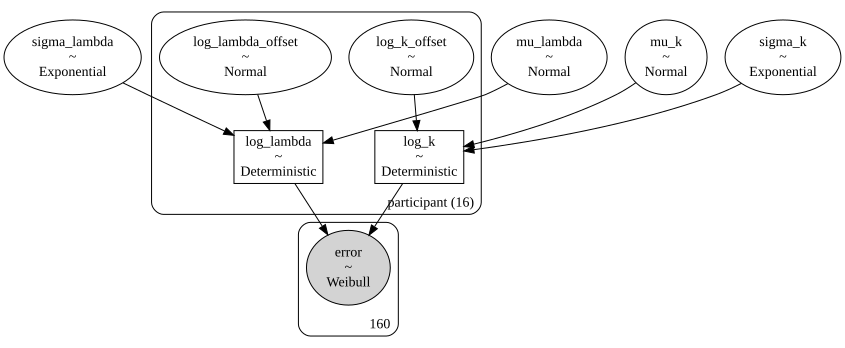

In [7]:
pm.model_to_graphviz(task2_y_weibull)

In [8]:
# fit the model 

with task2_y_weibull:
    task2_y_weibull_idata = pm.sample(
        draws=4000,
        tune=4000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed = 42, 
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_k, sigma_lambda, mu_k, mu_lambda, log_k_offset, log_lambda_offset]


                                                                               
                              Step      Grad      Sampli…                      
  Progre…   Draws   Diverg…   size      evals     Speed     Elapsed   Remain…  
 ───────────────────────────────────────────────────────────────────────────── 
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
                                        

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 62 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


In [9]:
az.summary(task2_y_weibull_idata)

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "C:\Users\slong\AppData\Roaming\uv\python\cpython-3.13.5-windows-x86_64-none\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_k,-0.694,0.116,-0.918,-0.479,0.001,0.001,9675.0,10090.0,1.0
mu_lambda,-5.061,0.261,-5.535,-4.565,0.003,0.005,7478.0,4604.0,1.0
log_k_offset[67f03733938aa3f0d17ce8a8],-0.482,0.637,-1.694,0.709,0.004,0.005,20300.0,11483.0,1.0
log_k_offset[5c8f2ac8d7ecab0018d529aa],-0.816,0.658,-2.049,0.410,0.005,0.006,20262.0,11546.0,1.0
log_k_offset[6740e1e09ca406ab781318cb],0.257,0.665,-1.028,1.485,0.005,0.006,19716.0,11616.0,1.0
...,...,...,...,...,...,...,...,...,...
log_lambda[671e36cc7fa293418ae65232],-5.343,0.470,-6.283,-4.489,0.004,0.004,16587.0,10439.0,1.0
log_lambda[67e2ab30a61684eccd40a3e3],-4.957,0.405,-5.693,-4.139,0.003,0.004,18504.0,12483.0,1.0
log_lambda[67e2f5ebbe69a58c40a5d550],-5.126,0.458,-6.027,-4.263,0.003,0.005,22605.0,12136.0,1.0
log_lambda[67ebfd4d8ea1101322300f73],-5.309,0.424,-6.113,-4.504,0.003,0.003,17917.0,13626.0,1.0


array([[<Axes: title={'center': 'mu_k'}>, <Axes: title={'center': 'mu_k'}>],
       [<Axes: title={'center': 'mu_lambda'}>,
        <Axes: title={'center': 'mu_lambda'}>],
       [<Axes: title={'center': 'log_k_offset'}>,
        <Axes: title={'center': 'log_k_offset'}>],
       [<Axes: title={'center': 'log_lambda_offset'}>,
        <Axes: title={'center': 'log_lambda_offset'}>],
       [<Axes: title={'center': 'sigma_k'}>,
        <Axes: title={'center': 'sigma_k'}>],
       [<Axes: title={'center': 'sigma_lambda'}>,
        <Axes: title={'center': 'sigma_lambda'}>],
       [<Axes: title={'center': 'log_k'}>, <Axes: title={'center': 'log_k'}>],
       [<Axes: title={'center': 'log_lambda'}>,
        <Axes: title={'center': 'log_lambda'}>]], dtype=object)

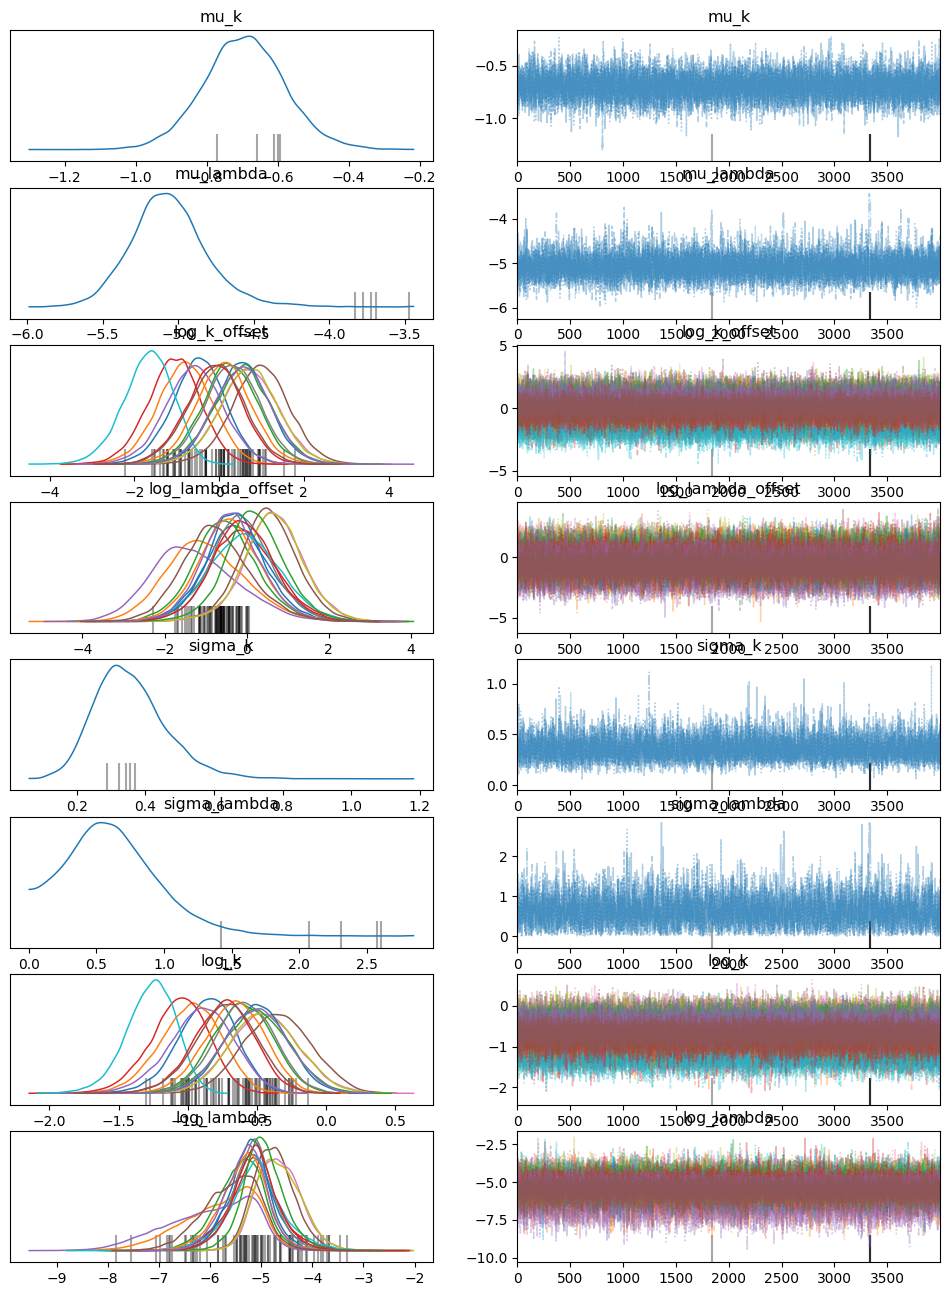

In [10]:
az.plot_trace(task2_y_weibull_idata, combined=True)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

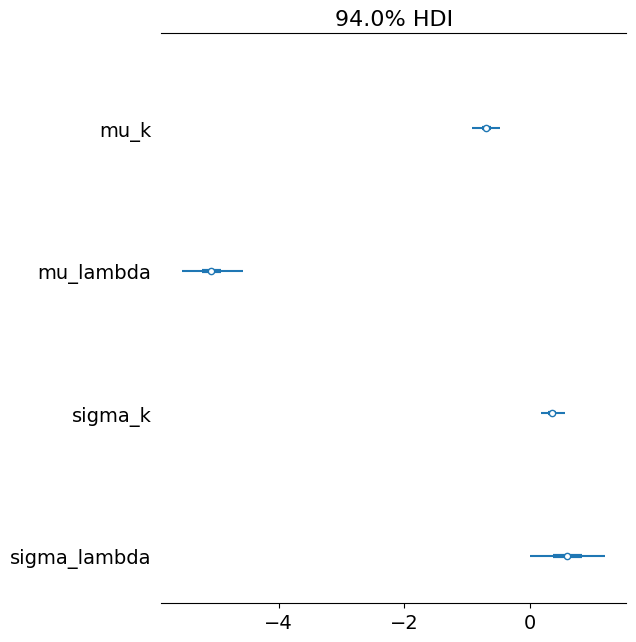

In [11]:
az.plot_forest(task2_y_weibull_idata, combined=True, var_names=["mu_k", "mu_lambda", "sigma_k", "sigma_lambda"])

In [12]:
# posterior predictive check 
with task2_y_weibull:
    pm.sample_posterior_predictive(task2_y_weibull_idata, extend_inferencedata=True)

Sampling: [error]


Sampling ... ---------------------------------------- 100% 0:00:00 / 0:00:01/ 0:00:01/ 0:00:01


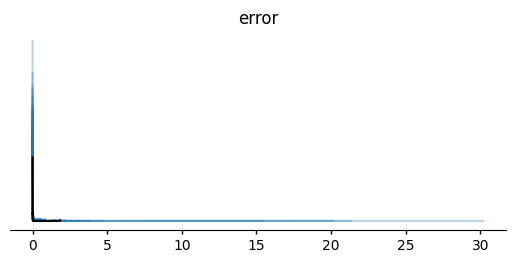

In [13]:
# azp.plot_ecdf_pit(task2_y_weibull_idata)
azp.plot_ppc_dist(task2_y_weibull_idata)

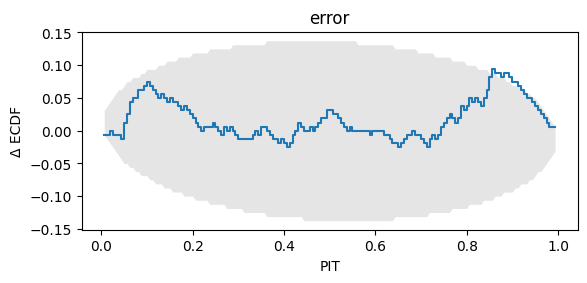

In [14]:
azp.plot_ppc_pit(task2_y_weibull_idata)

In [15]:
# save fit 
task2_y_weibull_idata.to_netcdf("../fitted_models/task2.y.weibull.nc")

'../fitted_models/task2.y.weibull.nc'

## X-Axis Error 

We will fit a Laplace model: 

$$
\begin{align*}
\text{error\_va}_{i} &\sim \text{Laplace}(\mu, b) \\
\mu_j &\sim \mathcal{N}(\bar{\mu}, \sigma_\mu) \\ 
\log(b_j) &\sim \mathcal{N}(\mu_b, \sigma_b) \\ 
\bar{\mu}, \mu_b &\sim \mathcal{N}(0, 1) \\ 
\sigma_\mu, \sigma_b &\sim \text{Half-Cauchy}(0, 1)
\end{align*}
$$

In [16]:
with pm.Model(coords={
    "participant": unq_pids
}) as task2_x_laplace:
    # hyperprior 
    # sigma_mu = pm.HalfCauchy("sigma_mu", 1)
    # sigma_b = pm.HalfCauchy("sigma_b", 1)
    sigma_mu = pm.Exponential("sigma_mu", 1)
    sigma_b = pm.Exponential("sigma_b", 1)
    mu_bar = pm.Normal("mu_bar", 0, 1)
    mu_b = pm.Normal("mu_b", 0, 1)

    # prior 
    mu_offset = pm.Normal("mu_offset", 0, 1, dims="participant")
    mu = pm.Deterministic("mu", mu_bar + sigma_mu * mu_offset, dims="participant")
    
    log_b_offset = pm.Normal("log_b_offset", 0, 1, dims="participant")
    log_b = pm.Deterministic("log_b", mu_b + log_b_offset * sigma_b, dims="participant")
    b = pm.math.exp(log_b[participant_idx])

    # likelihood 
    error = pm.Laplace("error", mu[participant_idx], b, observed=obv_error)

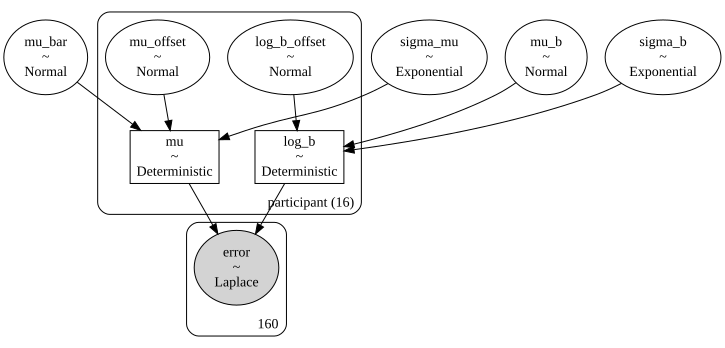

In [17]:
pm.model_to_graphviz(task2_x_laplace)

In [18]:
# fit the model 

with task2_x_laplace:
    task2_x_laplace_idata = pm.sample(
        draws=4000,
        tune=4000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed = 42, 
        progressbar=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_mu, sigma_b, mu_bar, mu_b, mu_offset, log_b_offset]


                                                                               
                              Step      Grad      Sampli…                      
  Progre…   Draws   Diverg…   size      evals     Speed     Elapsed   Remain…  
 ───────────────────────────────────────────────────────────────────────────── 
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
  -------   0       0         0.000     0         0.00      0:00:00   -:--:--  
                                                  draws/s                      
                                        

Sampling 4 chains for 4_000 tune and 4_000 draw iterations (16_000 + 16_000 draws total) took 399 seconds.


In [19]:
az.summary(task2_x_laplace_idata)

[autoreload of cutils_ext failed: Traceback (most recent call last):
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "C:\Users\slong\AppData\Roaming\uv\python\cpython-3.13.5-windows-x86_64-none\Lib\importlib\__init__.py", line 128, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'cutils_ext'
]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_bar,0.003,0.001,0.001,0.005,0.000,0.000,4779.0,6937.0,1.0
mu_b,-4.502,0.392,-5.204,-3.757,0.009,0.007,2000.0,3571.0,1.0
mu_offset[67f03733938aa3f0d17ce8a8],-0.102,0.776,-1.488,1.433,0.007,0.007,13113.0,9645.0,1.0
mu_offset[5c8f2ac8d7ecab0018d529aa],-1.084,0.459,-1.959,-0.233,0.006,0.004,6566.0,8738.0,1.0
mu_offset[6740e1e09ca406ab781318cb],-0.357,0.632,-1.504,0.875,0.007,0.006,9289.0,8716.0,1.0
...,...,...,...,...,...,...,...,...,...
log_b[671e36cc7fa293418ae65232],-5.233,0.328,-5.833,-4.611,0.002,0.003,24329.0,11913.0,1.0
log_b[67e2ab30a61684eccd40a3e3],-5.069,0.335,-5.681,-4.435,0.002,0.003,19671.0,12098.0,1.0
log_b[67e2f5ebbe69a58c40a5d550],-4.841,0.319,-5.409,-4.222,0.002,0.003,25860.0,12650.0,1.0
log_b[67ebfd4d8ea1101322300f73],-5.623,0.332,-6.261,-5.014,0.002,0.003,23898.0,11050.0,1.0


array([[<Axes: title={'center': 'mu_bar'}>,
        <Axes: title={'center': 'mu_bar'}>],
       [<Axes: title={'center': 'mu_b'}>, <Axes: title={'center': 'mu_b'}>],
       [<Axes: title={'center': 'mu_offset'}>,
        <Axes: title={'center': 'mu_offset'}>],
       [<Axes: title={'center': 'log_b_offset'}>,
        <Axes: title={'center': 'log_b_offset'}>],
       [<Axes: title={'center': 'sigma_mu'}>,
        <Axes: title={'center': 'sigma_mu'}>],
       [<Axes: title={'center': 'sigma_b'}>,
        <Axes: title={'center': 'sigma_b'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>],
       [<Axes: title={'center': 'log_b'}>, <Axes: title={'center': 'log_b'}>]],
      dtype=object)

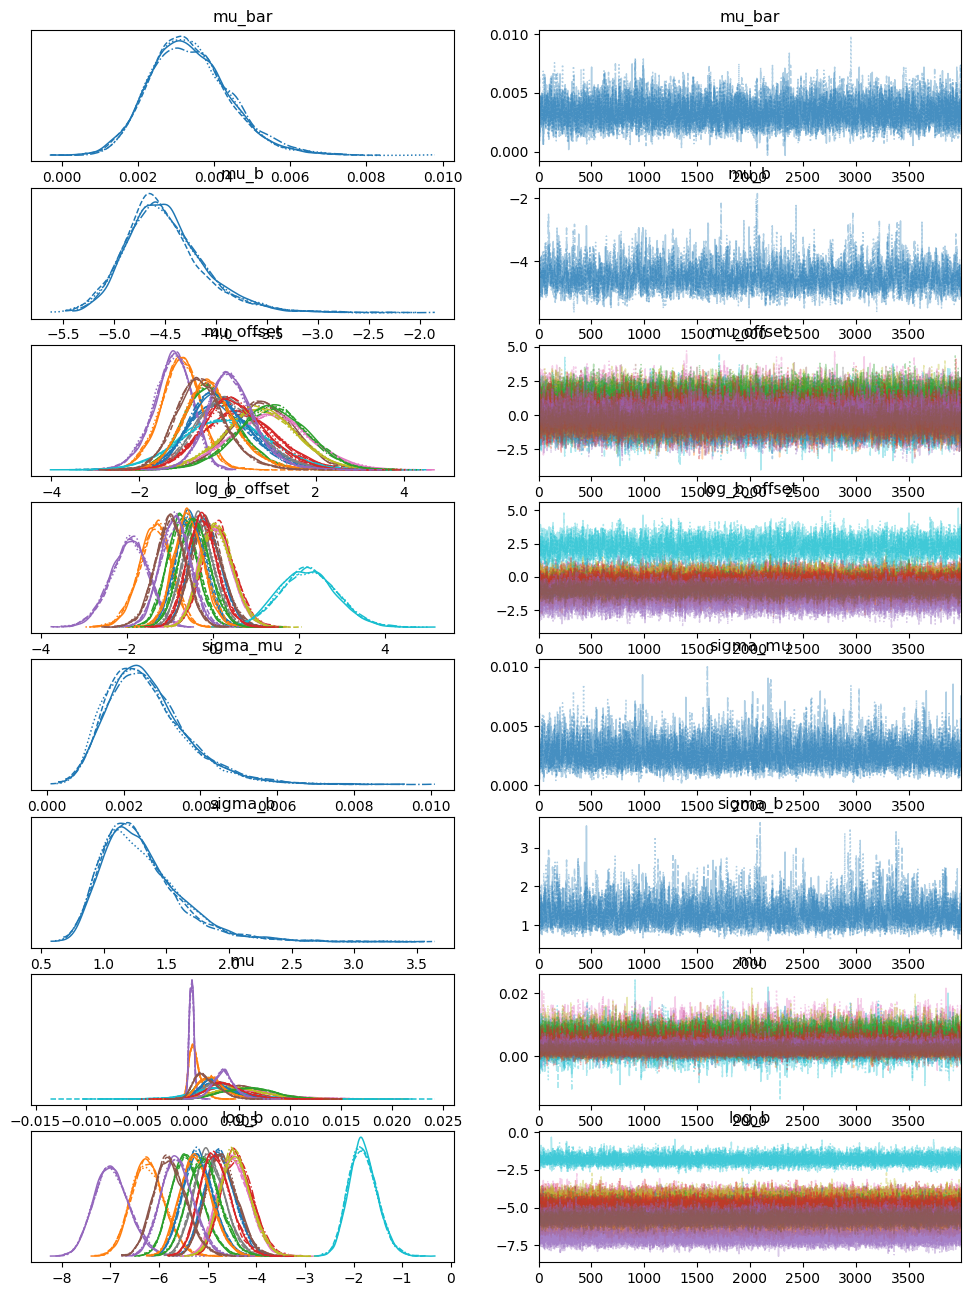

In [20]:
az.plot_trace(task2_x_laplace_idata)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

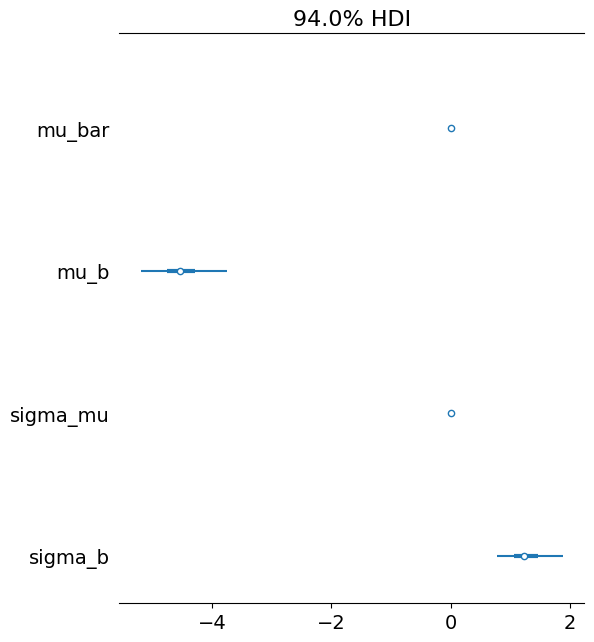

In [21]:
az.plot_forest(task2_x_laplace_idata, combined=True, var_names=["mu_bar", "mu_b", "sigma_mu", "sigma_b"])

In [22]:
# posterior predictive check 
with task2_x_laplace:
    pm.sample_posterior_predictive(task2_x_laplace_idata, extend_inferencedata=True)

Sampling: [error]


Sampling ... ---------------------------------------- 100% 0:00:00 / 0:00:01/ 0:00:01/ 0:00:01


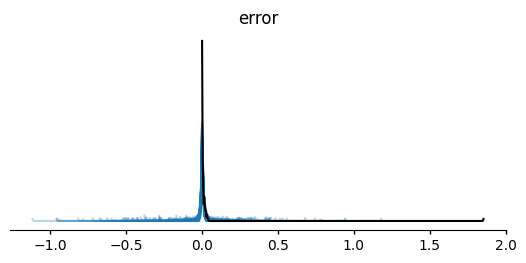

In [23]:
azp.plot_ppc_dist(task2_x_laplace_idata)

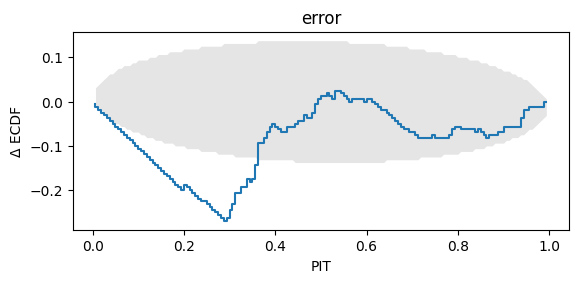

In [24]:
azp.plot_ppc_pit(task2_x_laplace_idata)

hmm ... ? for some reason this is not working out as well ...??? I don't get why the posterior predictive check shows such a bad result ... 

In [25]:
# save fitted data 
task2_x_laplace_idata.to_netcdf("../fitted_models/task2.x.laplace.nc")

'../fitted_models/task2.x.laplace.nc'